In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [2]:
import pandas as pd

# Load the dataset
import pandas as pd

df = [
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\raw\api_data_aadhar_biometric_0_500000.csv",
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\raw\api_data_aadhar_biometric_500000_1000000.csv",
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\raw\api_data_aadhar_biometric_1000000_1500000.csv",
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\raw\api_data_aadhar_biometric_1500000_1861108.csv"
]





In [3]:
chunk_size = 100000
data = []

for df in df:
    for chunk in pd.read_csv(df, chunksize=chunk_size):
        data.append(chunk)

df = pd.concat(data, ignore_index=True)

print(df.shape)


(1861108, 6)


In [4]:
# Display the first few rows
df.head()


,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,01-03-2025,Haryana,Mahendragarh,123029,280,577
1,01-03-2025,Bihar,Madhepura,852121,144,369
2,01-03-2025,Jammu and Kashmir,Punch,185101,643,1091
3,01-03-2025,Bihar,Bhojpur,802158,256,980
4,01-03-2025,Tamil Nadu,Madurai,625514,271,815


In [5]:
df.describe()

,pincode,bio_age_5_17,bio_age_17_
count,1.861108e+06,1.861108e+06,1.861108e+06
mean,5.217612e+05,1.839058e+01,1.909413e+01
std,1.981627e+05,8.370421e+01,8.806502e+01
min,1.100010e+05,0.000000e+00,0.000000e+00
25%,3.911750e+05,1.000000e+00,1.000000e+00
50%,5.224010e+05,3.000000e+00,4.000000e+00
75%,6.866362e+05,1.100000e+01,1.000000e+01
max,8.554560e+05,8.002000e+03,7.625000e+03


In [6]:
df.isnull().sum()

date            0
state           0
district        0
pincode         0
bio_age_5_17    0
bio_age_17_     0
dtype: int64

In [7]:
df.columns.tolist()



['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_']

In [8]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861108 entries, 0 to 1861107
Data columns (total 6 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   date          object
 1   state         object
 2   district      object
 3   pincode       int64 
 4   bio_age_5_17  int64 
 5   bio_age_17_   int64 
dtypes: int64(3), object(3)
memory usage: 85.2+ MB


In [9]:
df['date'].head()
df['date'].nunique()
df['date'].describe()




count        1861108
unique            89
top       25-12-2025
freq           24646
Name: date, dtype: object

In [10]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M').astype(str)

df[['date', 'year_month']].head()



,date,year_month
0,2025-01-03,2025-01
1,2025-01-03,2025-01
2,2025-01-03,2025-01
3,2025-01-03,2025-01
4,2025-01-03,2025-01


In [11]:
#Geography Coverage Check
df['state'].nunique(), df['district'].nunique(), df['pincode'].nunique()


(57, 974, 19707)

In [12]:
df.isnull().sum().sort_values(ascending=False)


date            944100
month           944100
year            944100
state                0
district             0
bio_age_5_17         0
pincode              0
bio_age_17_          0
year_month           0
dtype: int64

In [13]:
(df.isnull().mean() * 100).round(2)


date            50.73
state            0.00
district         0.00
pincode          0.00
bio_age_5_17     0.00
bio_age_17_      0.00
year            50.73
month           50.73
year_month       0.00
dtype: float64

In [14]:
#Sanity Check on Biometric Counts
df[['bio_age_5_17', 'bio_age_17_']].describe()


,bio_age_5_17,bio_age_17_
count,1.861108e+06,1.861108e+06
mean,1.839058e+01,1.909413e+01
std,8.370421e+01,8.806502e+01
min,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.000000e+00
50%,3.000000e+00,4.000000e+00
75%,1.100000e+01,1.000000e+01
max,8.002000e+03,7.625000e+03


In [15]:
#checking negativity
(df[['bio_age_5_17', 'bio_age_17_']] < 0).sum()


bio_age_5_17    0
bio_age_17_     0
dtype: int64

In [16]:
df.duplicated().sum()


np.int64(331623)

In [17]:
df.duplicated(
    subset=['date', 'state', 'district', 'pincode']
).sum()


np.int64(958907)

In [18]:
#Create Total Biometric Updates
df['bio_total'] = df['bio_age_5_17'] + df['bio_age_17_']

df[['bio_age_5_17', 'bio_age_17_', 'bio_total']].head()


,bio_age_5_17,bio_age_17_,bio_total
0,280,577,857
1,144,369,513
2,643,1091,1734
3,256,980,1236
4,271,815,1086


In [19]:
#Data processing

df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M').astype(str)

df[['date', 'year_month']].head()


,date,year_month
0,2025-01-03,2025-01
1,2025-01-03,2025-01
2,2025-01-03,2025-01
3,2025-01-03,2025-01
4,2025-01-03,2025-01


Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_',
       'year', 'month', 'year_month', 'bio_total'],
      dtype='object')
       bio_age_5_17   bio_age_17_
count  1.861108e+06  1.861108e+06
mean   1.839058e+01  1.909413e+01
std    8.370421e+01  8.806502e+01
min    0.000000e+00  0.000000e+00
25%    1.000000e+00  1.000000e+00
50%    3.000000e+00  4.000000e+00
75%    1.100000e+01  1.000000e+01
max    8.002000e+03  7.625000e+03
bio_age_5_17    0
bio_age_17_     0
dtype: int64


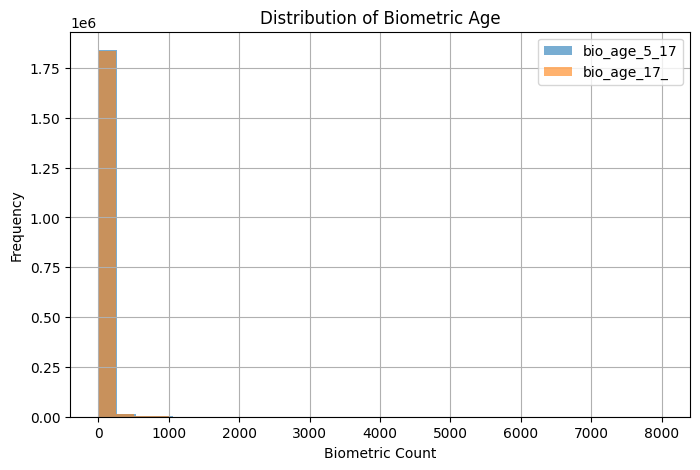

In [20]:
import matplotlib.pyplot as plt

# Check columns exist
print(df.columns)

plt.figure(figsize=(8,5))
plt.title('Distribution of Biometric Age')

# Statistics
print(df[['bio_age_5_17', 'bio_age_17_']].describe())

# Negative values check
print((df[['bio_age_5_17', 'bio_age_17_']] < 0).sum())

# Histograms
df['bio_age_5_17'].hist(alpha=0.6, bins=30)
df['bio_age_17_'].hist(alpha=0.6, bins=30)

plt.legend(['bio_age_5_17', 'bio_age_17_'])
plt.xlabel('Biometric Count')
plt.ylabel('Frequency')
plt.show()


In [21]:
mean_17 = df['bio_age_17_'].mean()
std_17 = df['bio_age_17_'].std()
threshold = mean_17 + 3 * std_17

df['anomaly_17'] = df['bio_age_17_'] > threshold


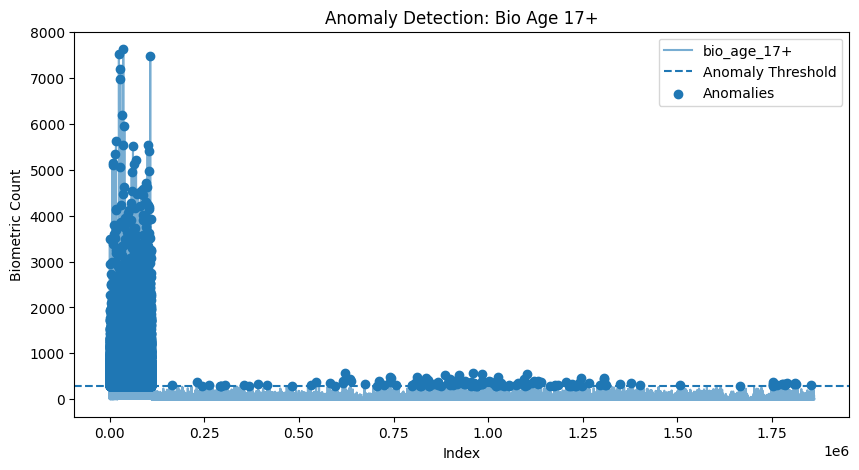

In [22]:
plt.figure(figsize=(10,5))
plt.plot(df['bio_age_17_'], label='bio_age_17+', alpha=0.6)

plt.axhline(threshold, linestyle='--', label='Anomaly Threshold')

plt.scatter(
    df[df['anomaly_17']].index,
    df[df['anomaly_17']]['bio_age_17_'],
    label='Anomalies'
)

plt.title('Anomaly Detection: Bio Age 17+')
plt.xlabel('Index')
plt.ylabel('Biometric Count')
plt.legend()
plt.show()


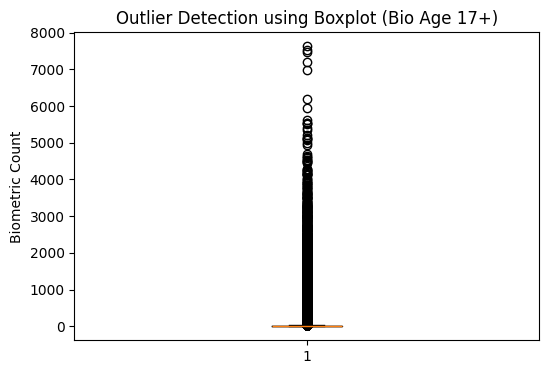

In [23]:
plt.figure(figsize=(6,4))
plt.boxplot(df['bio_age_17_'].dropna())
plt.title('Outlier Detection using Boxplot (Bio Age 17+)')
plt.ylabel('Biometric Count')
plt.show()


             district  bio_age_17_  anomaly
8          Ahmadnagar       199316     True
10          Ahmedabad       239599     True
26           Amravati       234714     True
51         Aurangabad       250924     True
354         Hyderabad       177501     True
365            Jaipur       197591     True
371           Jalgaon       268531     True
510             Latur       172366     True
586            Mumbai       284744     True
607            Nagpur       238072     True
616            Nanded       217810     True
626            Nashik       363506     True
654  North West Delhi       191718     True
704              Pune       322282     True
718           Raigarh       217212     True
821           Solapur       179884     True
870             Thane       368377     True
964          Yavatmal       234587     True


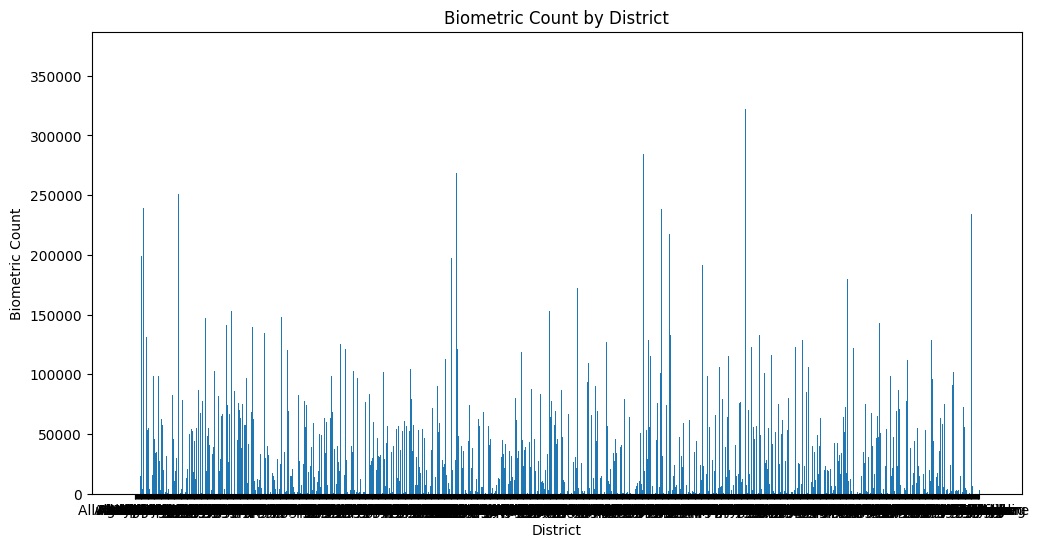

In [24]:
district_summary = (
    df.groupby('district')['bio_age_17_']
    .sum()
    .reset_index()
)

mean_d = district_summary['bio_age_17_'].mean()
std_d = district_summary['bio_age_17_'].std()

district_summary['anomaly'] = (
    district_summary['bio_age_17_'] > mean_d + 3 * std_d
)

print(district_summary[district_summary['anomaly']])

plt.figure(figsize=(12,6))
plt.bar(district_summary['district'], district_summary['bio_age_17_'])
plt.xlabel('District')
plt.ylabel('Biometric Count')
plt.title('Biometric Count by District')
plt.show()



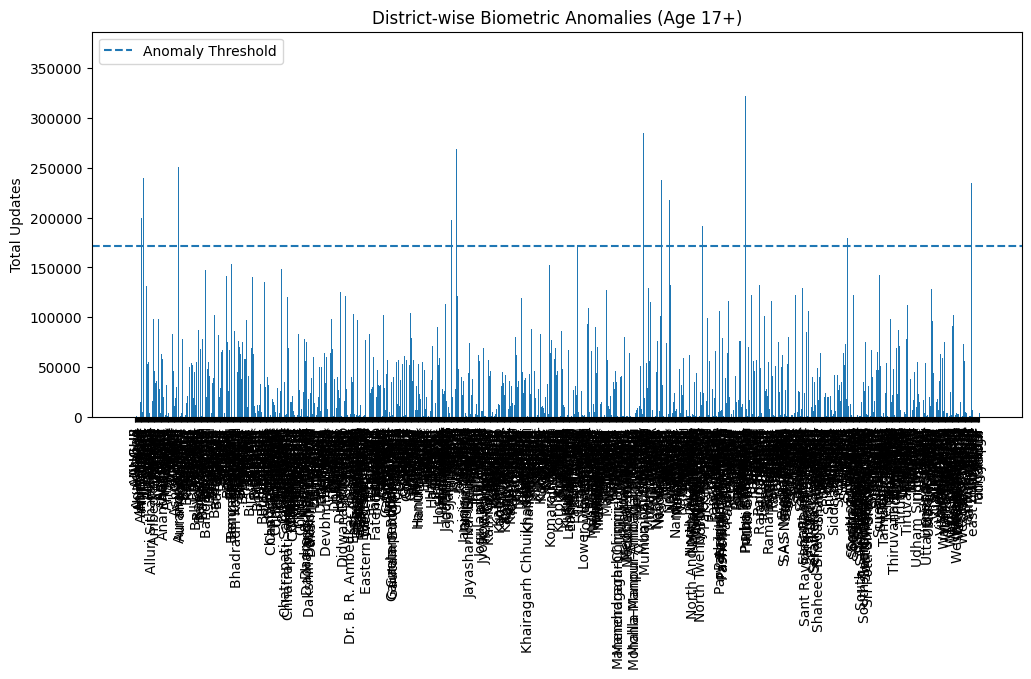

In [25]:

plt.figure(figsize=(12,5))
plt.bar(district_summary['district'], district_summary['bio_age_17_'])

plt.axhline(mean_d + 3*std_d, linestyle='--', label='Anomaly Threshold')

plt.xticks(rotation=90)
plt.title('District-wise Biometric Anomalies (Age 17+)')
plt.ylabel('Total Updates')
plt.legend()

plt.show()


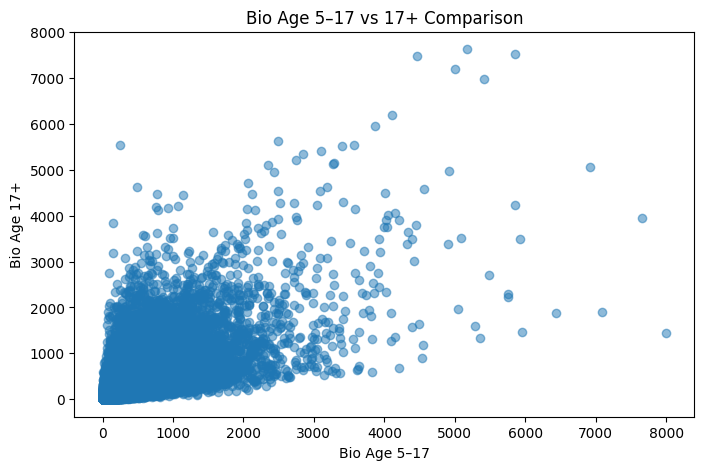

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(df['bio_age_5_17'], df['bio_age_17_'], alpha=0.5)

plt.title('Bio Age 5–17 vs 17+ Comparison')
plt.xlabel('Bio Age 5–17')
plt.ylabel('Bio Age 17+')
plt.show()


#### Solving the anomaly detection problem

It does NOT mean “delete the data”.

It means:
1. Identify anomalous records
2. Classify the reason
3. Validate with context
4. Decide action (keep / adjust / flag)


Detected anomalous biometric update spikes using statistical thresholds.
Anomalies were further validated using age-group ratios, district aggregation, and temporal patterns.
Rather than removing records, anomalies were flagged and classified as data quality issues, special enrollment drives, or potential misuse, ensuring auditability and policy compliance.

### Step-1: Is the anomaly REAL or DATA ERROR?

In [27]:
#Check 1: Negative or impossible values
df[df['bio_age_17_'] < 0]


,date,state,district,pincode,bio_age_5_17,bio_age_17_,year,month,year_month,bio_total,anomaly_17


In [28]:
#Action: Replace with NaN or remove
df.loc[df['bio_age_17_'] < 0, 'bio_age_17_'] = None


In [29]:
#Check 2: Sudden single-row spike
df.sort_values('bio_age_17_', ascending=False).head(10)


,date,state,district,pincode,bio_age_5_17,bio_age_17_,year,month,year_month,bio_total,anomaly_17
36088,2025-01-04,Delhi,North West Delhi,110086,5180,7625.0,2025.0,1.0,2025-01,12805,True
24461,2025-01-04,Delhi,South Delhi,110062,5861,7520.0,2025.0,1.0,2025-01,13381,True
107288,2025-01-07,Maharashtra,Aurangabad,431001,4469,7472.0,2025.0,1.0,2025-01,11941,True
28235,2025-01-04,Delhi,West Delhi,110059,5003,7201.0,2025.0,1.0,2025-01,12204,True
28311,2025-01-04,Delhi,South Delhi,110044,5411,6984.0,2025.0,1.0,2025-01,12395,True
32284,2025-01-04,Delhi,North West Delhi,110042,4112,6188.0,2025.0,1.0,2025-01,10300,True
38950,2025-01-04,Delhi,West Delhi,110041,3866,5950.0,2025.0,1.0,2025-01,9816,True
16706,2025-01-03,Maharashtra,Aurangabad,431001,2490,5616.0,2025.0,1.0,2025-01,8106,True
35859,2025-01-04,Delhi,North East,110094,242,5548.0,2025.0,1.0,2025-01,5790,True
100286,2025-01-07,Madhya Pradesh,Burhanpur,450331,3574,5534.0,2025.0,1.0,2025-01,9108,True


### Step-2: Compare with RELATED VARIABLES (MOST IMPORTANT)

In [30]:
# High 17+ updates but low 5–17 updates = suspicious
df['ratio_17_to_5'] = df['bio_age_17_'] / (df['bio_age_5_17'] + 1)


In [31]:

suspicious = df[df['ratio_17_to_5'] > 10]
print(suspicious.shape)


(5767, 12)


### Step-3: Contextual Validation (District / Time)

In [32]:
#District-level validation
district_check = (
    df.groupby('district')[['bio_age_5_17', 'bio_age_17_']]
    .sum()
    .reset_index()
)

# Check for districts with zero biometric counts
district_check[(district_check['bio_age_5_17'] == 0) | (district_check['bio_age_17_'] == 0)]



,district,bio_age_5_17,bio_age_17_
0,?,0,1.0
13,Akhera,0,1.0
40,Anugal,0,4.0
42,Anugul *,0,1.0
50,Auraiya *,1,0.0
56,BALANGIR,0,1.0
72,Bally Jagachha,0,5.0
75,Balotra,0,6.0
81,Bandipur,0,1.0
166,Chandauli *,0,1.0


### Step-4: Time-based Validation

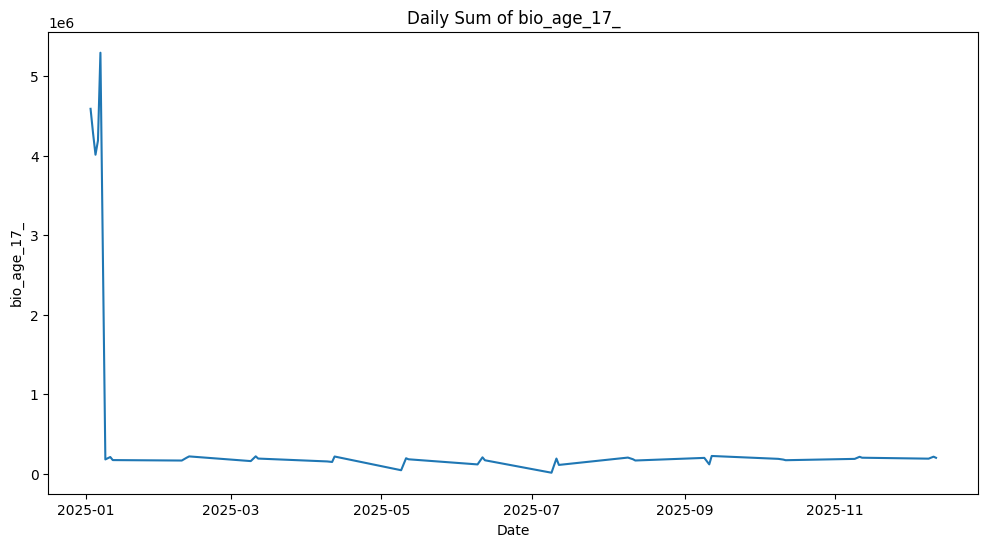

In [33]:
df['date'] = pd.to_datetime(df['date'])

daily = (
    df.groupby('date')['bio_age_17_']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))
plt.plot(daily['date'], daily['bio_age_17_'])
plt.title('Daily Sum of bio_age_17_')
plt.xlabel('Date')
plt.ylabel('bio_age_17_')
plt.show()


In [34]:
df['anomaly_flag'] = (
    df['bio_age_17_'] > df['bio_age_17_'].mean() + 3*df['bio_age_17_'].std()
)


In [35]:
upper_cap = df['bio_age_17_'].quantile(0.99)
df['bio_age_17_'] = df['bio_age_17_'].clip(upper=upper_cap)


In [36]:
df['bio_total'] = df['bio_age_5_17'] + df['bio_age_17_']
df[['bio_age_5_17', 'bio_age_17_', 'bio_total']].head()


,bio_age_5_17,bio_age_17_,bio_total
0,280,324.0,604.0
1,144,324.0,468.0
2,643,324.0,967.0
3,256,324.0,580.0
4,271,324.0,595.0


In [37]:
#Aggregation

df_agg = df.groupby(
    ['year_month', 'state', 'district'],
    as_index=False
)[['bio_age_5_17', 'bio_age_17_', 'bio_total']].sum()

df_agg.head()


,year_month,state,district,bio_age_5_17,bio_age_17_,bio_total
0,2025-01,Andaman & Nicobar Islands,Andamans,96,923.0,1019.0
1,2025-01,Andaman & Nicobar Islands,Nicobars,1,0.0,1.0
2,2025-01,Andaman & Nicobar Islands,South Andaman,1,10.0,11.0
3,2025-01,Andaman and Nicobar Islands,Nicobar,534,513.0,1047.0
4,2025-01,Andaman and Nicobar Islands,North And Middle Andaman,2102,2074.0,4176.0


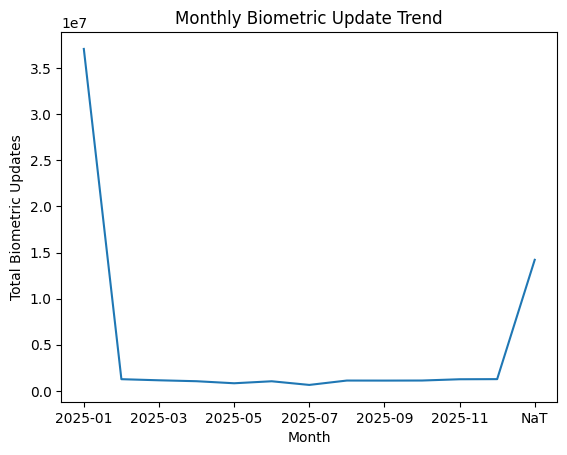

In [38]:
#Trend Analysis
monthly_trend = df_agg.groupby('year_month')['bio_total'].sum()

monthly_trend.plot(title='Monthly Biometric Update Trend')
plt.xlabel('Month')
plt.ylabel('Total Biometric Updates')
plt.show()


In [39]:
#Age Transition Analysis
df_agg['transition_ratio'] = (
    df_agg['bio_age_17_'] /
    (df_agg['bio_age_5_17'] + 1)
)

df_agg


,year_month,state,district,bio_age_5_17,bio_age_17_,bio_total,transition_ratio
0,2025-01,Andaman & Nicobar Islands,Andamans,96,923.0,1019.0,9.515464
1,2025-01,Andaman & Nicobar Islands,Nicobars,1,0.0,1.0,0.000000
2,2025-01,Andaman & Nicobar Islands,South Andaman,1,10.0,11.0,5.000000
3,2025-01,Andaman and Nicobar Islands,Nicobar,534,513.0,1047.0,0.958879
4,2025-01,Andaman and Nicobar Islands,North And Middle Andaman,2102,2074.0,4176.0,0.986210
...,...,...,...,...,...,...,...
12805,NaT,Westbengal,Hooghly,0,4.0,4.0,4.000000
12806,NaT,Westbengal,Howrah,0,1.0,1.0,1.000000
12807,NaT,andhra pradesh,chittoor,8,7.0,15.0,0.777778
12808,NaT,andhra pradesh,rangareddi,1,4.0,5.0,2.000000


In [40]:
df_agg[['transition_ratio']].describe()


,transition_ratio
count,12810.000000
mean,1.738394
std,3.247046
min,0.000000
25%,0.628249
50%,1.000000
75%,1.609344
max,110.000000


In [41]:
#Anomaly Detection

mean = df_agg['bio_total'].mean()
std = df_agg['bio_total'].std()

df_agg['z_score'] = (df_agg['bio_total'] - mean) / std

anomalies = df_agg[abs(df_agg['z_score']) > 3]
anomalies.head()


,year_month,state,district,bio_age_5_17,bio_age_17_,bio_total,transition_ratio,z_score
9,2025-01,Andhra Pradesh,Anantapur,21756,32540.0,54296.0,1.495611,3.086284
10,2025-01,Andhra Pradesh,Ananthapur,50370,11369.0,61739.0,0.225705,3.551562
11,2025-01,Andhra Pradesh,Ananthapuramu,71315,12098.0,83413.0,0.169639,4.906453
14,2025-01,Andhra Pradesh,Chittoor,112611,45759.0,158370.0,0.406342,9.592184
15,2025-01,Andhra Pradesh,Cuddapah,79058,31442.0,110500.0,0.397703,6.599722


In [42]:
#Total Biometric Load
df_agg['signal_bio_load'] = df_agg['bio_total']



In [43]:
#Adult Transition Pressure
df_agg['signal_transition_pressure'] = (
    df_agg['bio_age_17_'] /
    (df_agg['bio_total'] + 1)
)


In [44]:
#Child Biometric Share
df_agg['signal_child_share'] = (
    df_agg['bio_age_5_17'] /
    (df_agg['bio_total'] + 1)
)


In [45]:
#Biometric Growth Rate (Time-based Signal)
df_agg = df_agg.sort_values(
    by=['state', 'district', 'year_month']
)


In [46]:
df_agg['signal_bio_growth'] = (
    df_agg.groupby(['state', 'district'])['bio_total']
          .pct_change()
)


In [47]:
#Biometric Volatility Index
df_agg['signal_bio_volatility'] = (
    df_agg.groupby(['state', 'district'])['bio_total']
          .rolling(window=3)
          .std()
          .reset_index(level=[0,1], drop=True)
)


In [48]:
#Clean Signal Dataset
biometric_signals = df_agg[[
    'year_month',
    'state',
    'district',
    'signal_bio_load',
    'signal_transition_pressure',
    'signal_child_share',
    'signal_bio_growth',
    'signal_bio_volatility'
]]


In [49]:
biometric_signals = biometric_signals.fillna(0)


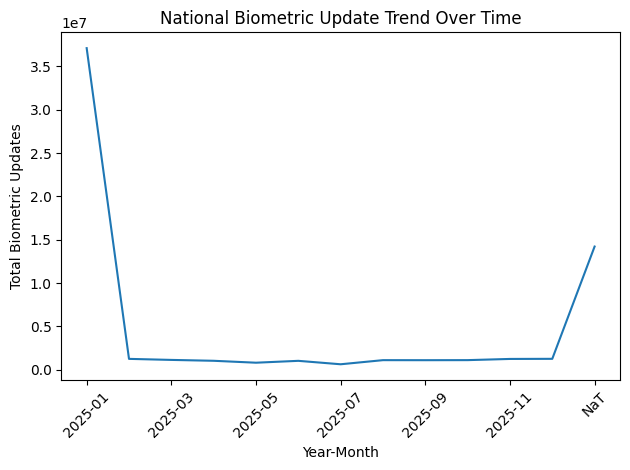

In [50]:
#National Biometric Load Trend
national_trend = biometric_signals.groupby('year_month')['signal_bio_load'].sum()

plt.figure()
national_trend.plot()
plt.title("National Biometric Update Trend Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Total Biometric Updates")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


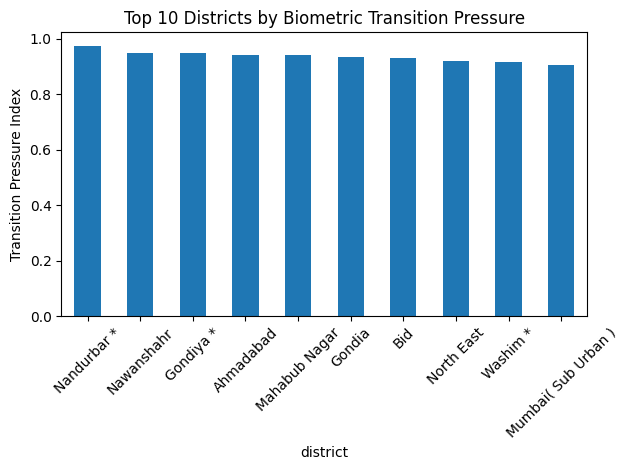

In [51]:
#District Transition Pressure (Top 10)
top_transition = (
    biometric_signals.groupby('district')['signal_transition_pressure']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
top_transition.plot(kind='bar')
plt.title("Top 10 Districts by Biometric Transition Pressure")
plt.ylabel("Transition Pressure Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


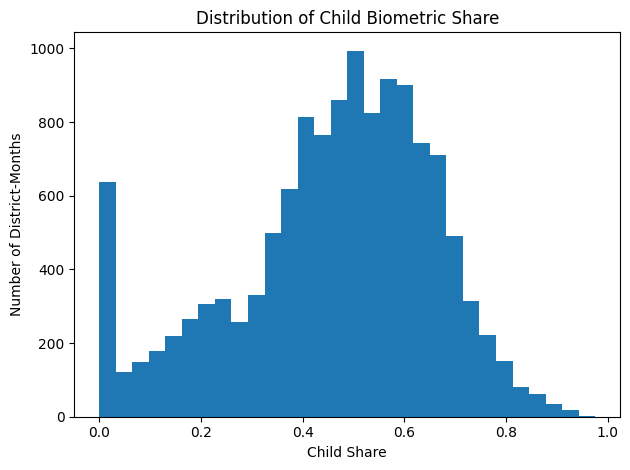

In [52]:
#Child vs Adult Biometric Share (Distribution)
plt.figure()
plt.hist(biometric_signals['signal_child_share'], bins=30)
plt.title("Distribution of Child Biometric Share")
plt.xlabel("Child Share")
plt.ylabel("Number of District-Months")
plt.tight_layout()
plt.show()



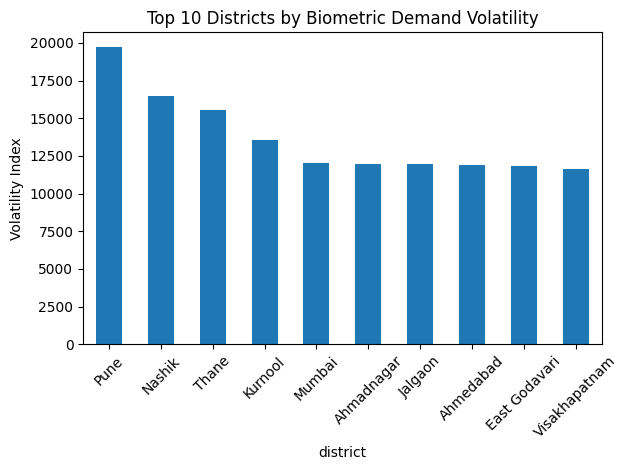

In [53]:
#Biometric Volatility Heat Indicator
volatility_summary = (
    biometric_signals.groupby('district')['signal_bio_volatility']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
volatility_summary.plot(kind='bar')
plt.title("Top 10 Districts by Biometric Demand Volatility")
plt.ylabel("Volatility Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


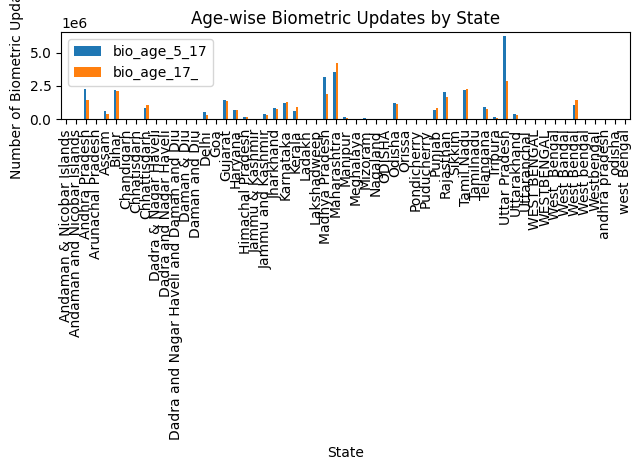

In [54]:
#AGE-WISE BIOMETRIC UPDATES BY STATE
state_age = (
    df_agg
    .groupby('state')[['bio_age_5_17', 'bio_age_17_']]
    .sum()
)

state_age.plot(kind='bar')
plt.title("Age-wise Biometric Updates by State")
plt.xlabel("State")
plt.ylabel("Number of Biometric Updates")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


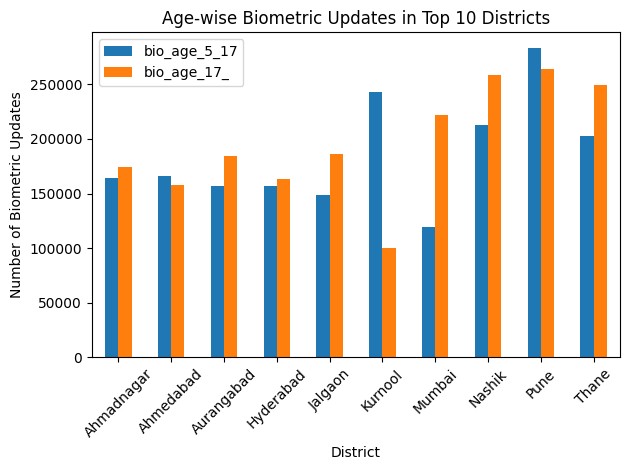

In [55]:
#AGE-WISE BIOMETRIC UPDATES — TOP DISTRICTS
top_districts = (
    df_agg.groupby('district')['bio_total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

district_age = (
    df_agg[df_agg['district'].isin(top_districts)]
    .groupby('district')[['bio_age_5_17', 'bio_age_17_']]
    .sum()
)

district_age.plot(kind='bar')
plt.title("Age-wise Biometric Updates in Top 10 Districts")
plt.xlabel("District")
plt.ylabel("Number of Biometric Updates")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


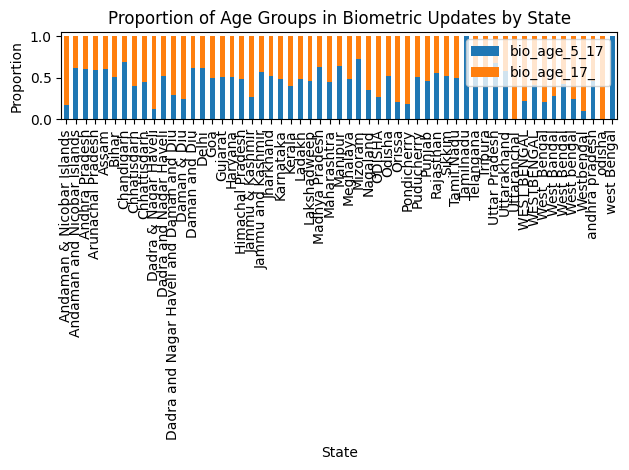

In [56]:
#AGE COMPOSITION — STATE LEVEL (STACKED BAR)
state_age_pct = state_age.div(state_age.sum(axis=1), axis=0)

state_age_pct.plot(kind='bar', stacked=True)
plt.title("Proportion of Age Groups in Biometric Updates by State")
plt.xlabel("State")
plt.ylabel("Proportion")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


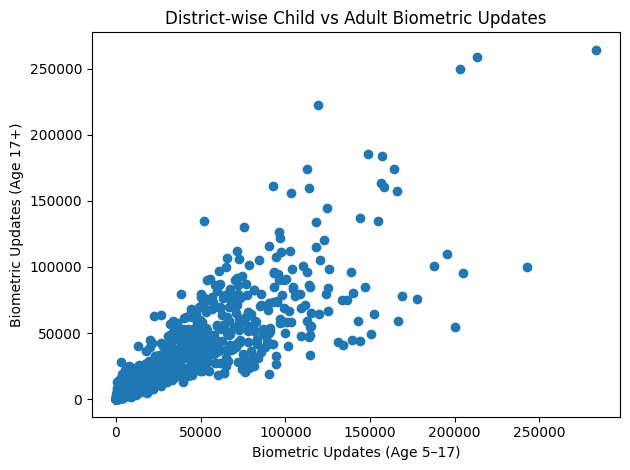

In [57]:
#DISTRICT-LEVEL AGE DOMINANCE (SCATTER COMPARISON)
district_compare = (
    df_agg
    .groupby('district')[['bio_age_5_17', 'bio_age_17_']]
    .sum()
)

plt.figure()
plt.scatter(
    district_compare['bio_age_5_17'],
    district_compare['bio_age_17_']
)
plt.xlabel("Biometric Updates (Age 5–17)")
plt.ylabel("Biometric Updates (Age 17+)")
plt.title("District-wise Child vs Adult Biometric Updates")
plt.tight_layout()
plt.show()



In [58]:
df.columns

Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_',
       'year', 'month', 'year_month', 'bio_total', 'anomaly_17',
       'ratio_17_to_5', 'anomaly_flag'],
      dtype='object')

In [59]:
#Feature Selection
features_df = df_agg[[
    'year_month',
    'state',
    'district',
    'bio_age_5_17',
    'bio_age_17_',
    'bio_total',
    'signal_transition_pressure',
    'signal_child_share',
    'signal_bio_growth',
    'signal_bio_volatility'
]]


In [60]:
#FEATURE PREPROCESSING
features_df = features_df.fillna(0)


In [61]:
#Encode Time
features_df['year'] = pd.to_datetime(features_df['year_month']).dt.year
features_df['month'] = pd.to_datetime(features_df['year_month']).dt.month


In [62]:
features_df = features_df.drop(columns=['year_month'])


In [63]:
#Encode Geography
features_df['state_code'] = features_df['state'].astype('category').cat.codes
features_df['district_code'] = features_df['district'].astype('category').cat.codes


In [64]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

num_cols = [
    'bio_age_5_17',
    'bio_age_17_',
    'bio_total',
    'signal_transition_pressure',
    'signal_child_share',
    'signal_bio_growth',
    'signal_bio_volatility'
]

scaler = StandardScaler()
features_df[num_cols] = scaler.fit_transform(features_df[num_cols])


In [65]:
#FEATURE ENGINEERING
features_df['feat_bio_dependency'] = (
    features_df['bio_total'] /
    (features_df['bio_age_5_17'] + 1)
)


In [66]:
#Lifecycle Imbalance Score
features_df['feat_lifecycle_imbalance'] = (
    features_df['bio_age_17_'] - features_df['bio_age_5_17']
)


In [67]:
#Rolling Demand Momentum
features_df = features_df.sort_values(
    by=['state', 'district', 'year', 'month']
)

features_df['feat_3m_momentum'] = (
    features_df.groupby(['state', 'district'])['bio_total']
               .rolling(window=3)
               .mean()
               .reset_index(level=[0,1], drop=True)
)


In [68]:
features_df['feat_3m_momentum'] = features_df['feat_3m_momentum'].fillna(0)


Predict future biometric service demand at district level to support proactive infrastructure planning and resource allocation.

In [69]:
ml_df = features_df.sort_values(
    by=['state', 'district', 'year', 'month']
)


ml_df['target_bio_next_month'] = (
    ml_df.groupby(['state', 'district'])['bio_total']
         .shift(-1)
)

ml_df['target_bio_next_month'].isnull().sum()

ml_df['target_bio_next_month'].fillna(0, inplace=True)


In [70]:
# Create Lag Features (Past 1, 2, and 3 months) to capture recent trends
# Sort to ensure correct shifting
ml_df = ml_df.sort_values(by=['state', 'district', 'year', 'month'])

# Lag 1: Value from 1 month ago
ml_df['lag_1m_bio'] = ml_df.groupby(['state', 'district'])['bio_total'].shift(1)

# Lag 2: Value from 2 months ago
ml_df['lag_2m_bio'] = ml_df.groupby(['state', 'district'])['bio_total'].shift(2)

# Lag 3: Value from 3 months ago
ml_df['lag_3m_bio'] = ml_df.groupby(['state', 'district'])['bio_total'].shift(3)

# Rolling Standard Deviation (Volatility) - recalculating on raw bio_total for explicit feature
ml_df['rolling_std_3m'] = ml_df.groupby(['state', 'district'])['bio_total'].rolling(3).std().reset_index(level=[0,1], drop=True)

# Fill NaN values created by shifting (first few months will have NaNs)
ml_df = ml_df.fillna(0)

In [71]:
feature_cols = [
    'bio_age_5_17',
    'bio_age_17_',
    'signal_transition_pressure',
    'signal_child_share',
    'signal_bio_growth',
    'signal_bio_volatility',
    'feat_bio_dependency',
    'feat_lifecycle_imbalance',
    'feat_3m_momentum',
    'lag_1m_bio',       # New Feature
    'lag_2m_bio',       # New Feature
    'lag_3m_bio',       # New Feature
    'rolling_std_3m',   # New Feature
    'year',
    'month',
    'state_code',
    'district_code'
]

X = ml_df[feature_cols]
y = ml_df['target_bio_next_month']

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)


In [73]:
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting often performs better for regression on temporal data compared to Random Forest
model = GradientBoostingRegressor(
    n_estimators=500,       # Increased number of trees
    learning_rate=0.05,     # Lower learning rate for better generalization
    max_depth=6,            # Slightly deeper trees to capture district nuances
    min_samples_leaf=5,     # Prevent overfitting
    random_state=42
)

model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_depth,6
,min_impurity_decrease,0.0
,init,None


In [74]:
y_pred = model.predict(X_test)


In [75]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R² Score:", r2)


MAE: 0.03258444847675227
R² Score: 0.9459869154319074


In [76]:
#FEATURE IMPORTANCE
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

feature_importance.head(10)


feat_bio_dependency    0.458204
month                  0.308905
bio_age_17_            0.131467
feat_3m_momentum       0.027822
lag_1m_bio             0.021284
year                   0.013067
bio_age_5_17           0.007894
lag_2m_bio             0.006140
rolling_std_3m         0.005791
state_code             0.005440
dtype: float64

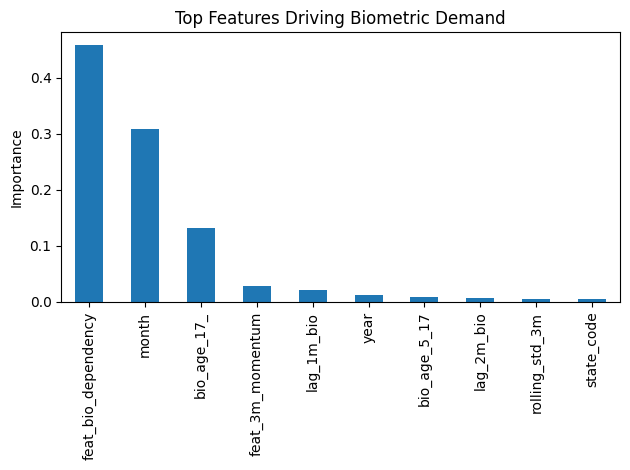

In [77]:
feature_importance.head(10).plot(kind='bar')
plt.title("Top Features Driving Biometric Demand")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


In [78]:
sample_predictions = X_test[['state_code', 'district_code']].copy()

sample_predictions['biometric_match'] = y_pred
sample_predictions['actual'] = y_test.values
sample_predictions['predicted'] = y_pred

sample_predictions.to_csv('sample_predictions.csv', index=False)



In [79]:

sample_predictions.head()


,state_code,district_code,biometric_match,actual,predicted
1777,42,118,-0.259179,-0.282200,-0.259179
2763,42,118,-0.277708,-0.267510,-0.277708
3752,42,118,-0.278722,-0.291703,-0.278722
4733,42,118,-0.277503,-0.282200,-0.277503
5707,42,118,-0.289785,-0.294078,-0.289785


In [80]:
df_agg[df_agg['district'] == 'Chittoor'] \
      .groupby('year_month')['bio_total'].sum()



year_month
2025-01    158370.0
2025-02      3057.0
2025-03      3124.0
2025-04      5566.0
2025-05      3574.0
2025-06      4028.0
2025-07      1918.0
2025-08      3063.0
2025-09      2340.0
2025-10      2536.0
2025-11      2654.0
2025-12      3392.0
NaT         53311.0
Name: bio_total, dtype: float64

In [81]:
df.to_csv(
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\processed\clean_biometric_data.csv",
    index=False
)


In [82]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\processed\clean_biometric_data.csv"
)

print(df.columns.tolist())


C:\Users\Shakil Ahmad\AppData\Local\Temp\ipykernel_9816\4192365695.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_', 'year', 'month', 'year_month', 'bio_total', 'anomaly_17', 'ratio_17_to_5', 'anomaly_flag']


=== Regression Metrics ===
Mean Absolute Error (MAE): 0.032584
Root Mean Squared Error (RMSE): 0.087389
R² Score: 0.9460
Safe MAPE: 1426054103.6011%


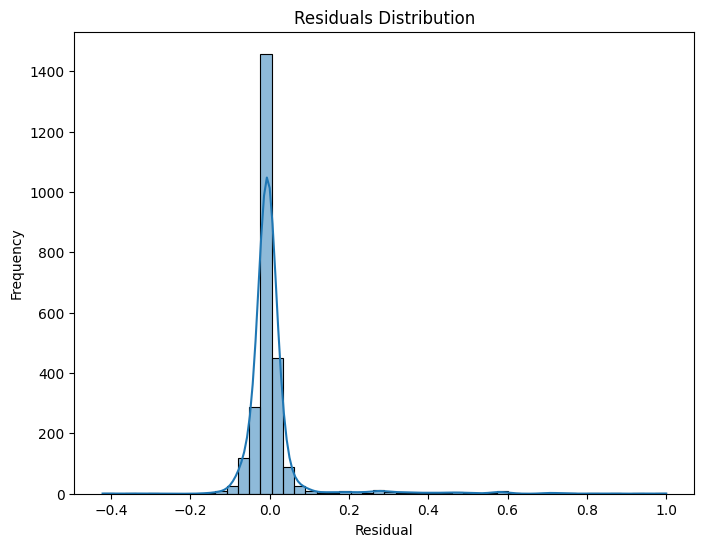

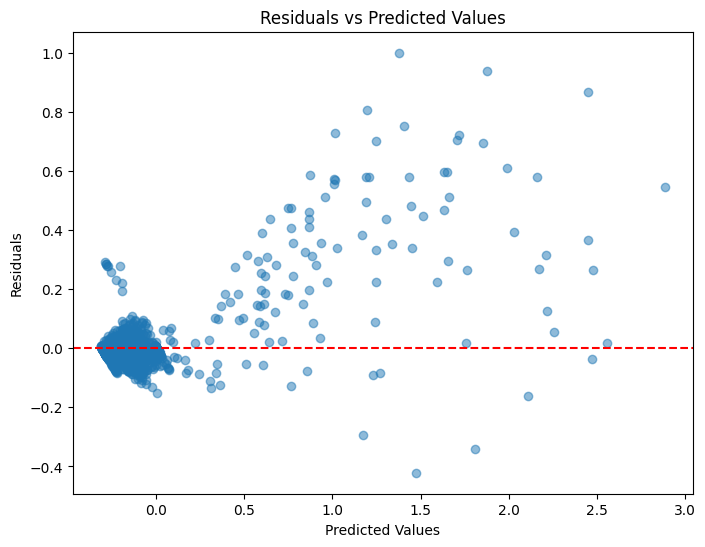

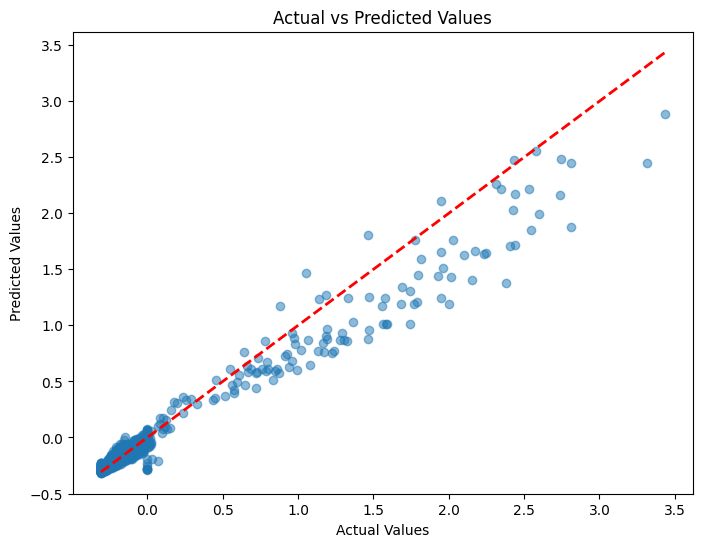

=== Top 10 Outliers ===
         Actual  Predicted  Residual  AbsResidual
11613  2.376487   1.376528  0.999959     0.999959
11603  2.814153   1.876423  0.937729     0.937729
11558  3.317833   2.451184  0.866649     0.866649
11625  1.998773   1.193137  0.805636     0.805636
11695  2.157311   1.405848  0.751463     0.751463
11638  1.743276   1.015812  0.727464     0.727464
11674  2.437439   1.716661  0.720778     0.720778
11645  2.409370   1.705000  0.704370     0.704370
11617  1.949387   1.247017  0.702370     0.702370
11622  2.545589   1.852117  0.693472     0.693472


In [86]:
# ==========================
# Regression Model Evaluation Block
# ==========================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------
# 1️⃣ Predictions
# --------------------------
y_pred = model.predict(X_test)  # your model predictions
residuals = y_test - y_pred

# --------------------------
# 2️⃣ Metrics
# --------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Safe MAPE (avoids division by zero or negative targets)
epsilon = 1e-10
safe_mape = np.mean(np.abs((y_test - y_pred) / (np.abs(y_test) + epsilon))) * 100

print("=== Regression Metrics ===")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R² Score: {r2:.4f}")
print(f"Safe MAPE: {safe_mape:.4f}%")

# --------------------------
# 3️⃣ Residual Analysis
# --------------------------
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

# --------------------------
# 4️⃣ Outlier Detection
# --------------------------
residuals_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Residual': residuals
})
residuals_df['AbsResidual'] = residuals_df['Residual'].abs()

# Top 10 largest errors
top_outliers = residuals_df.sort_values(by='AbsResidual', ascending=False).head(10)
print("=== Top 10 Outliers ===")
print(top_outliers)
